In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
columns = ["Variance","Skewness","Curtosis","Entropy","Class"]

df = pd.read_csv("data_banknote_authentication.txt",
                 names=columns)

print(df.head())

   Variance  Skewness  Curtosis  Entropy  Class
0   3.62160    8.6661   -2.8073 -0.44699      0
1   4.54590    8.1674   -2.4586 -1.46210      0
2   3.86600   -2.6383    1.9242  0.10645      0
3   3.45660    9.5228   -4.0112 -3.59440      0
4   0.32924   -4.4552    4.5718 -0.98880      0


In [ ]:
print("Shape:",df.shape)

print("\nMissing Values")
print(df.isnull().sum())

print("\nDataset Info")
print(df.info())

print("\nStatistics")
print(df.describe())

Shape: (1372, 5)

Missing Values
Variance    0
Skewness    0
Curtosis    0
Entropy     0
Class       0
dtype: int64

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Variance  1372 non-null   float64
 1   Skewness  1372 non-null   float64
 2   Curtosis  1372 non-null   float64
 3   Entropy   1372 non-null   float64
 4   Class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB
None

Statistics
          Variance     Skewness     Curtosis      Entropy        Class
count  1372.000000  1372.000000  1372.000000  1372.000000  1372.000000
mean      0.433735     1.922353     1.397627    -1.191657     0.444606
std       2.842763     5.869047     4.310030     2.101013     0.497103
min      -7.042100   -13.773100    -5.286100    -8.548200     0.000000
25%      -1.773000    -1.708200    -1.574975    -2.413450     0.0000

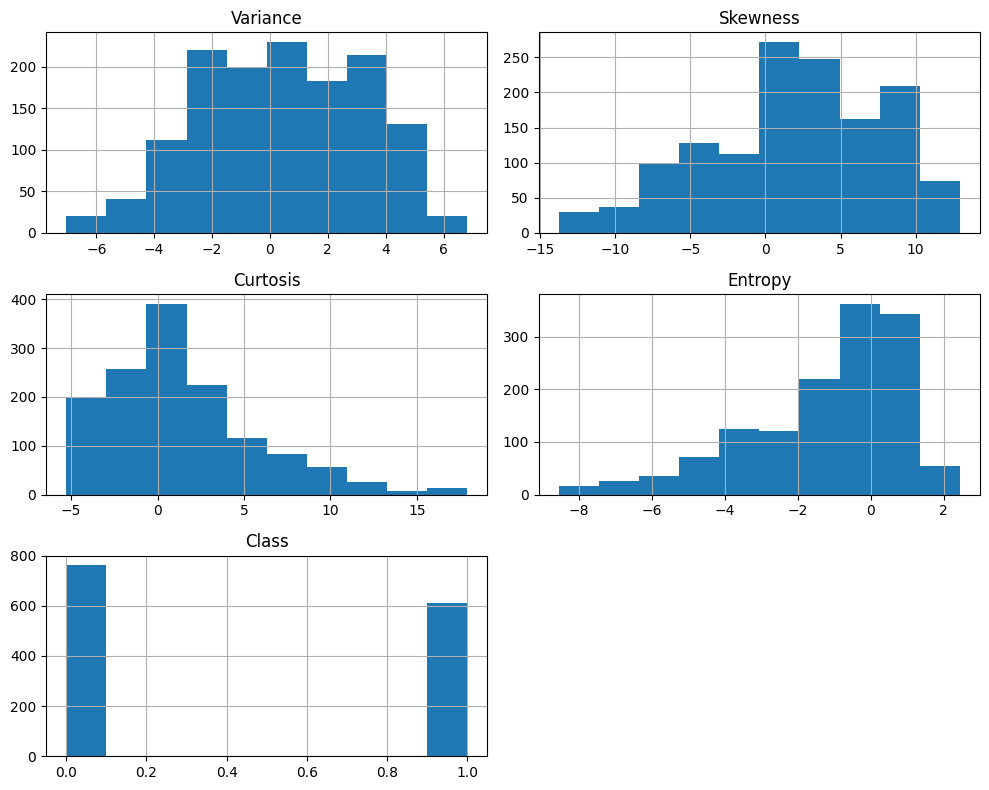

In [ ]:
df.hist(figsize=(10,8))
plt.tight_layout()
plt.show()

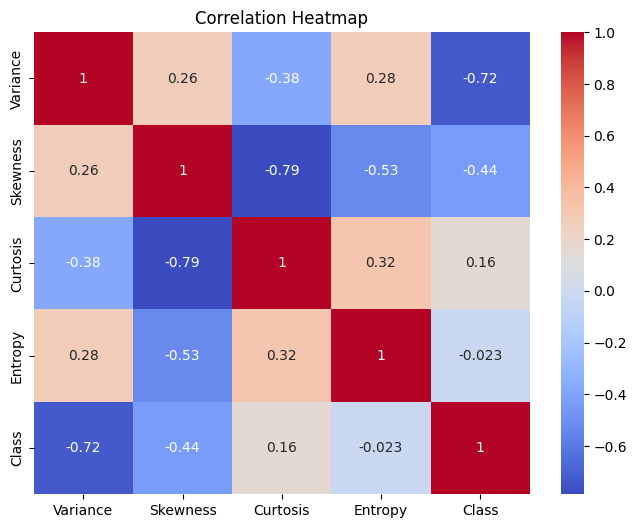

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

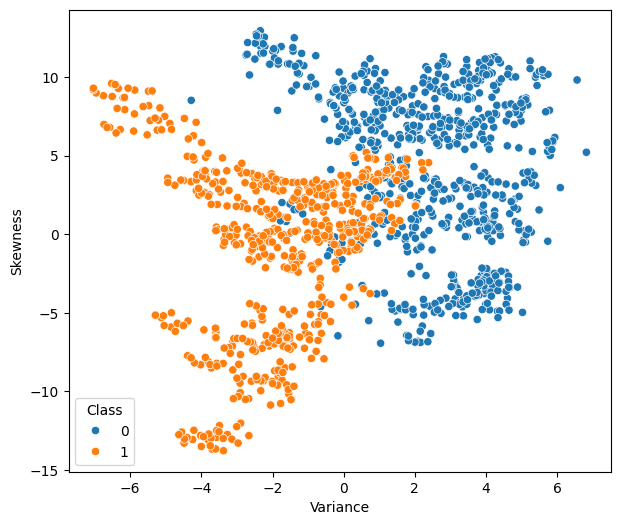

In [ ]:
plt.figure(figsize=(7,6))

sns.scatterplot(
    x="Variance",
    y="Skewness",
    hue="Class",
    data=df
)

plt.show()

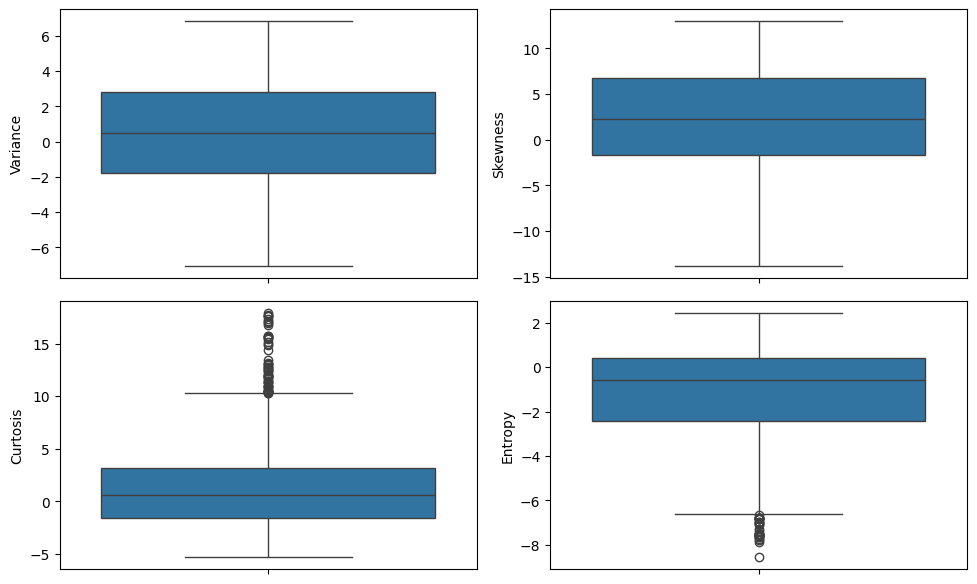

In [ ]:
plt.figure(figsize=(10,6))

for i,col in enumerate(df.columns[:-1]):
    plt.subplot(2,2,i+1)
    sns.boxplot(y=df[col])

plt.tight_layout()
plt.show()

In [ ]:
X = df.iloc[:,:-1].values
y = df.iloc[:,-1].values

scaler = MinMaxScaler()

X = scaler.fit_transform(X)

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
import numpy as np

class Perceptron:

    def __init__(self, lr=0.01, epochs=20):
        self.lr = lr
        self.epochs = epochs
        self.weights = None
        self.bias = 0

    def activation(self, z):
        return np.where(z >= 0, 1, 0)

    def fit(self, X, y):

        n_features = X.shape[1]

        self.weights = np.zeros(n_features)
        self.bias = 0

        self.errors = []
        self.weight_history = []
        self.bias_history = []

        for epoch in range(self.epochs):

            errors = 0

            for xi, target in zip(X, y):

                z = np.dot(xi, self.weights) + self.bias
                prediction = self.activation(z)

                update = self.lr * (target - prediction)

                self.weights += update * xi
                self.bias += update

                if update != 0:
                    errors += 1

            self.errors.append(errors)
            self.weight_history.append(self.weights.copy())
            self.bias_history.append(self.bias)

            print(f"Epoch {epoch+1}: Errors = {errors}")

    def predict(self, X):
        z = np.dot(X, self.weights) + self.bias
        return self.activation(z)

In [ ]:
model = Perceptron(lr=0.01, epochs=20)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

Epoch 1: Errors = 166
Epoch 2: Errors = 88
Epoch 3: Errors = 57
Epoch 4: Errors = 51
Epoch 5: Errors = 47
Epoch 6: Errors = 45
Epoch 7: Errors = 48
Epoch 8: Errors = 32
Epoch 9: Errors = 19
Epoch 10: Errors = 40
Epoch 11: Errors = 35
Epoch 12: Errors = 28
Epoch 13: Errors = 40
Epoch 14: Errors = 31
Epoch 15: Errors = 28
Epoch 16: Errors = 38
Epoch 17: Errors = 27
Epoch 18: Errors = 28
Epoch 19: Errors = 32
Epoch 20: Errors = 31


In [ ]:
y_pred=model.predict(X_test)

print("Accuracy :",accuracy_score(y_test,y_pred))

print("Precision :",precision_score(y_test,y_pred))

print("Recall :",recall_score(y_test,y_pred))

print("F1 Score :",f1_score(y_test,y_pred))

Accuracy : 0.9745454545454545
Precision : 0.9477611940298507
Recall : 1.0
F1 Score : 0.9731800766283525


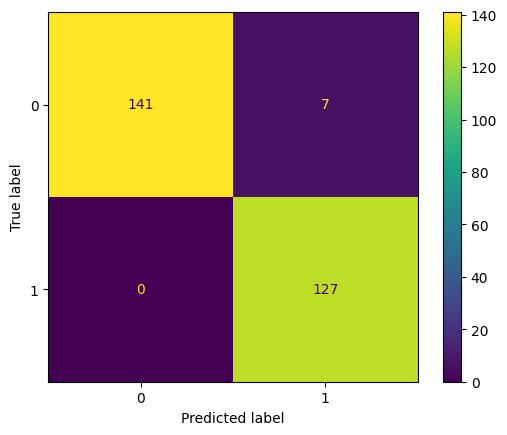

In [ ]:
cm=confusion_matrix(y_test,y_pred)

disp=ConfusionMatrixDisplay(cm)

disp.plot()

plt.show()

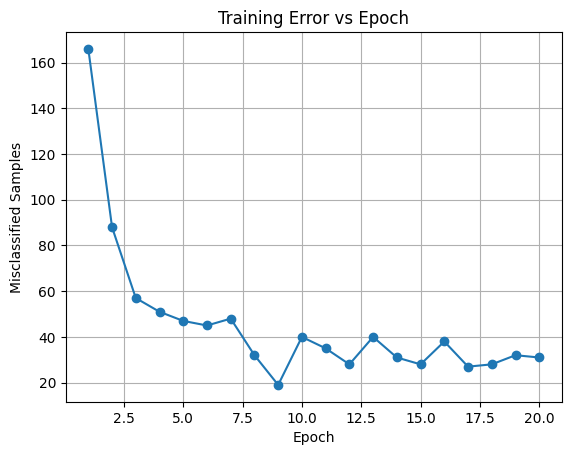

In [ ]:
plt.plot(range(1,len(model.errors)+1),
         model.errors,
         marker='o')

plt.xlabel("Epoch")

plt.ylabel("Misclassified Samples")

plt.title("Training Error vs Epoch")

plt.grid()

plt.show()

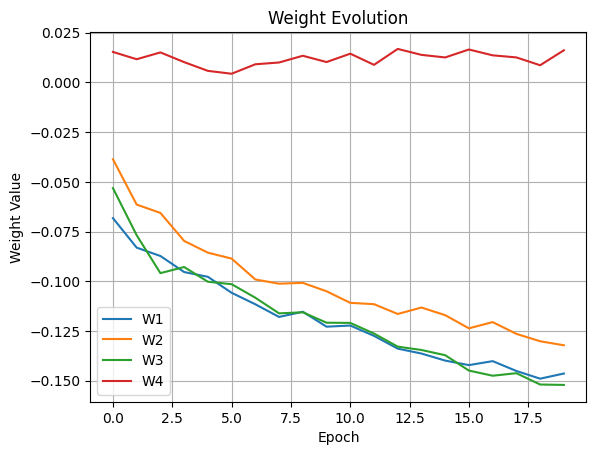

In [ ]:
weights=np.array(model.weight_history)

for i in range(weights.shape[1]):
    plt.plot(weights[:,i],label=f"W{i+1}")

plt.legend()

plt.xlabel("Epoch")

plt.ylabel("Weight Value")

plt.title("Weight Evolution")

plt.grid()

plt.show()

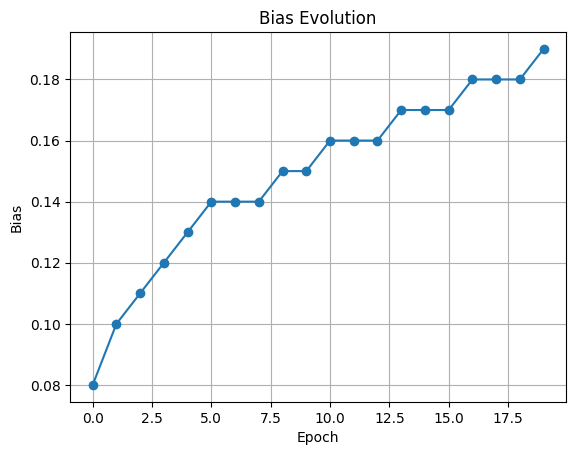

In [ ]:
plt.plot(model.bias_history,
         marker='o')

plt.xlabel("Epoch")

plt.ylabel("Bias")

plt.title("Bias Evolution")

plt.grid()

plt.show()

Epoch 1: Errors = 166
Epoch 2: Errors = 88
Epoch 3: Errors = 57
Epoch 4: Errors = 51
Epoch 5: Errors = 47
Epoch 6: Errors = 45
Epoch 7: Errors = 48
Epoch 8: Errors = 32
Epoch 9: Errors = 19
Epoch 10: Errors = 40
Epoch 11: Errors = 35
Epoch 12: Errors = 28
Epoch 13: Errors = 40
Epoch 14: Errors = 31
Epoch 15: Errors = 28
Epoch 16: Errors = 38
Epoch 17: Errors = 27
Epoch 18: Errors = 28
Epoch 19: Errors = 32
Epoch 20: Errors = 31
Epoch 1: Errors = 166
Epoch 2: Errors = 88
Epoch 3: Errors = 57
Epoch 4: Errors = 51
Epoch 5: Errors = 47
Epoch 6: Errors = 45
Epoch 7: Errors = 48
Epoch 8: Errors = 32
Epoch 9: Errors = 19
Epoch 10: Errors = 40
Epoch 11: Errors = 35
Epoch 12: Errors = 28
Epoch 13: Errors = 40
Epoch 14: Errors = 31
Epoch 15: Errors = 28
Epoch 16: Errors = 38
Epoch 17: Errors = 27
Epoch 18: Errors = 28
Epoch 19: Errors = 32
Epoch 20: Errors = 31
Epoch 1: Errors = 166
Epoch 2: Errors = 88
Epoch 3: Errors = 57
Epoch 4: Errors = 51
Epoch 5: Errors = 47
Epoch 6: Errors = 45
Epoch 7: 

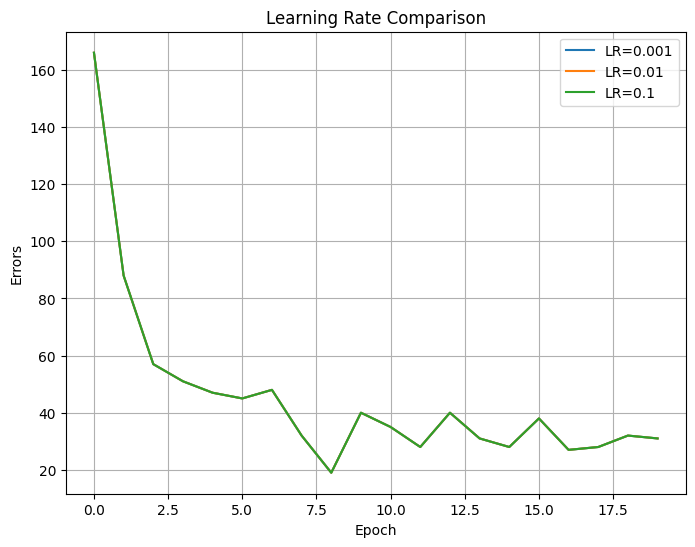

In [ ]:
rates=[0.001,0.01,0.1]

plt.figure(figsize=(8,6))

for lr in rates:

    p=Perceptron(
        lr=lr,
        epochs=20
    )

    p.fit(X_train,y_train)

    plt.plot(p.errors,label=f"LR={lr}")

plt.legend()

plt.xlabel("Epoch")

plt.ylabel("Errors")

plt.title("Learning Rate Comparison")

plt.grid()

plt.show()

In [ ]:
import pandas as pd

training_summary = pd.DataFrame({
    "Parameter": [
        "Dataset Size",
        "Train/Test Split",
        "Learning Rate",
        "Epochs",
        "Final Weights",
        "Final Bias",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    "Value": [
        len(df),
        f"{len(X_train)} / {len(X_test)}",
        model.lr,
        model.epochs,
        np.round(model.weights, 4),
        round(model.bias, 4),
        round(accuracy_score(y_test, y_pred), 4),
        round(precision_score(y_test, y_pred, zero_division=0), 4),
        round(recall_score(y_test, y_pred, zero_division=0), 4),
        round(f1_score(y_test, y_pred, zero_division=0), 4)
    ]
})

print(training_summary)

          Parameter                                Value
0      Dataset Size                                 1372
1  Train/Test Split                           1097 / 275
2     Learning Rate                                 0.01
3            Epochs                                   20
4     Final Weights  [-0.1464, -0.1322, -0.1521, 0.0161]
5        Final Bias                                 0.19
6          Accuracy                               0.9745
7         Precision                               0.9478
8            Recall                                  1.0
9          F1-score                               0.9732


In [22]:
class Perceptron:

    def __init__(self, lr=0.1, epochs=20):
        self.lr = lr
        self.epochs = epochs
        self.weights = None
        self.bias = 0

    def activation(self, x):
        return 1 if x >= 0 else 0

    def predict(self, X):
        linear = np.dot(X, self.weights) + self.bias
        return np.array([self.activation(i) for i in linear])

    def plot_boundary(self, X, y, title):

        # ---------- NOT Gate ----------
        if X.shape[1] == 1:

            plt.figure(figsize=(5,2))

            colors = ['red' if i==0 else 'blue' for i in y]

            plt.scatter(X[:,0], np.zeros(len(X)),
                        c=colors, s=120)

            if abs(self.weights[0]) > 1e-8:
                threshold = -self.bias/self.weights[0]
                plt.axvline(threshold,
                            color='black',
                            label='Decision Boundary')

            plt.yticks([])
            plt.xlim(-0.5,1.5)
            plt.grid(True)
            plt.title(title)
            plt.legend()
            plt.show()

            return

        # ---------- AND / OR / XOR ----------

        plt.figure(figsize=(5,5))

        colors = ['red' if i==0 else 'blue' for i in y]

        plt.scatter(X[:,0], X[:,1],
                    c=colors,
                    s=120)

        if abs(self.weights[1]) > 1e-8:

            x = np.linspace(-0.5,1.5,100)

            y_line = -(self.weights[0]*x+self.bias)/self.weights[1]

            plt.plot(x,y_line,
                     'k-',
                     label='Decision Boundary')

        plt.xlim(-0.5,1.5)
        plt.ylim(-0.5,1.5)
        plt.grid(True)
        plt.title(title)
        plt.legend()
        plt.show()

    def fit(self, X, y, gate_name):

        self.weights = np.zeros(X.shape[1])
        self.bias = 0

        update = 1

        print("\n===================================")
        print(f"Training Perceptron for {gate_name}")
        print("===================================")

        for epoch in range(self.epochs):

            error_count = 0

            for xi, target in zip(X, y):

                linear = np.dot(xi, self.weights) + self.bias

                pred = self.activation(linear)

                error = target - pred

                if error != 0:

                    self.weights += self.lr * error * xi
                    self.bias += self.lr * error

                    print(f"\nUpdate {update}")
                    print("Input :", xi)
                    print("Target :", target)
                    print("Prediction :", pred)
                    print("Weights :", self.weights)
                    print("Bias :", self.bias)

                    # Plot every update except limit XOR to first 10
                    if gate_name == "XOR":
                        if update <= 10:
                            self.plot_boundary(
                                X,
                                y,
                                f"{gate_name} Update {update}"
                            )
                    else:
                        self.plot_boundary(
                            X,
                            y,
                            f"{gate_name} Update {update}"
                        )

                    update += 1
                    error_count += 1

            if error_count == 0:
                print("\nConverged Successfully!")
                break

        print("\nFinal Weights :", self.weights)
        print("Final Bias :", self.bias)
        print("Predictions :", self.predict(X))


Training Perceptron for AND

Update 1
Input : [0 0]
Target : 0
Prediction : 1
Weights : [0. 0.]
Bias : -0.1


/tmp/ipykernel_4494/1771394628.py:67: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


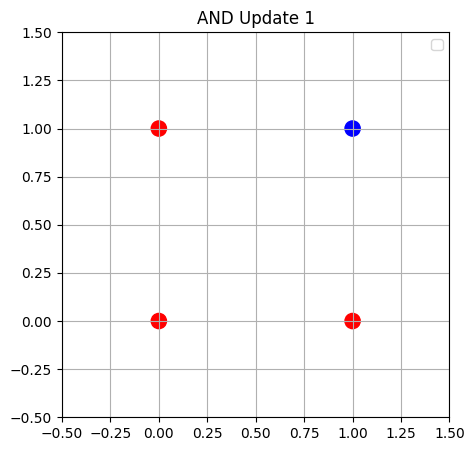


Update 2
Input : [1 1]
Target : 1
Prediction : 0
Weights : [0.1 0.1]
Bias : 0.0


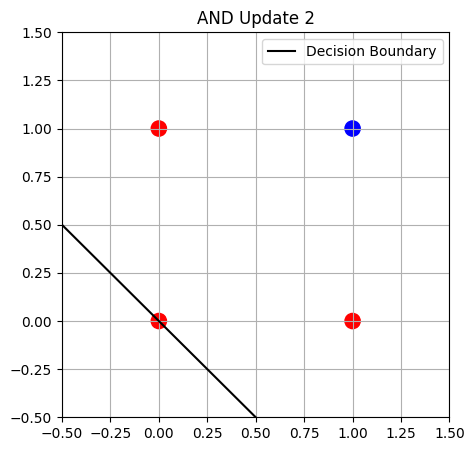


Update 3
Input : [0 0]
Target : 0
Prediction : 1
Weights : [0.1 0.1]
Bias : -0.1


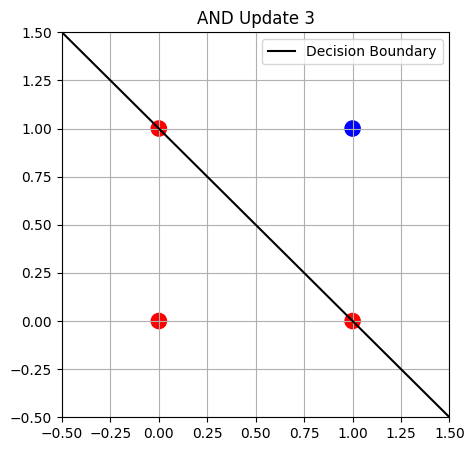


Update 4
Input : [0 1]
Target : 0
Prediction : 1
Weights : [0.1 0. ]
Bias : -0.2


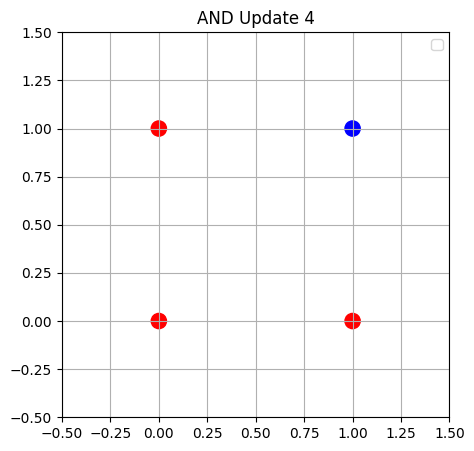


Update 5
Input : [1 1]
Target : 1
Prediction : 0
Weights : [0.2 0.1]
Bias : -0.1


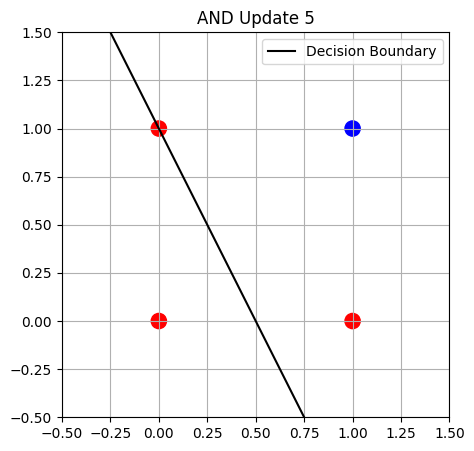


Update 6
Input : [0 1]
Target : 0
Prediction : 1
Weights : [0.2 0. ]
Bias : -0.2


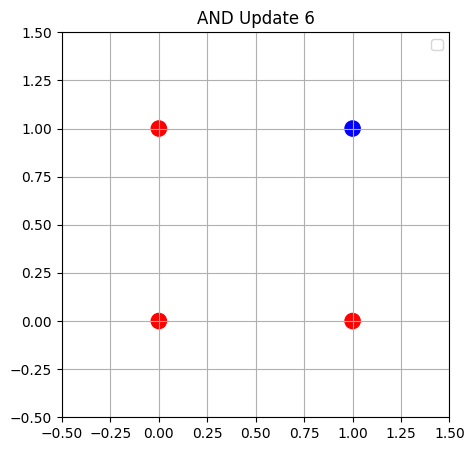


Update 7
Input : [1 0]
Target : 0
Prediction : 1
Weights : [0.1 0. ]
Bias : -0.30000000000000004


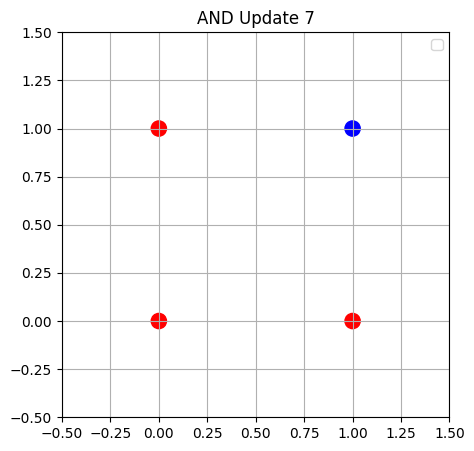


Update 8
Input : [1 1]
Target : 1
Prediction : 0
Weights : [0.2 0.1]
Bias : -0.20000000000000004


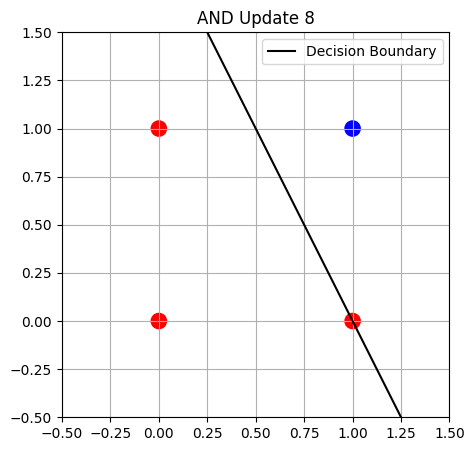


Converged Successfully!

Final Weights : [0.2 0.1]
Final Bias : -0.20000000000000004
Predictions : [0 0 0 1]


In [23]:
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y = np.array([0,0,0,1])

model = Perceptron(lr=0.1, epochs=20)
model.fit(X, y, "AND")


Training Perceptron for OR

Update 1
Input : [0 0]
Target : 0
Prediction : 1
Weights : [0. 0.]
Bias : -0.1


/tmp/ipykernel_4494/1771394628.py:67: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


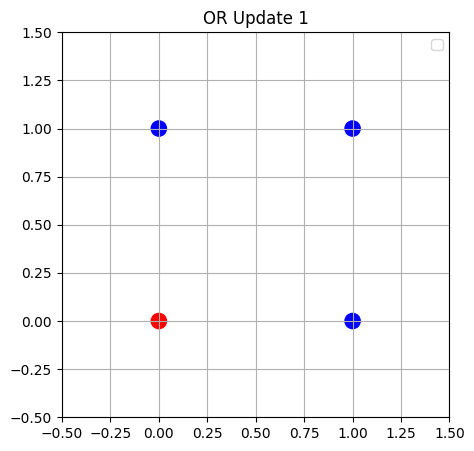


Update 2
Input : [0 1]
Target : 1
Prediction : 0
Weights : [0.  0.1]
Bias : 0.0


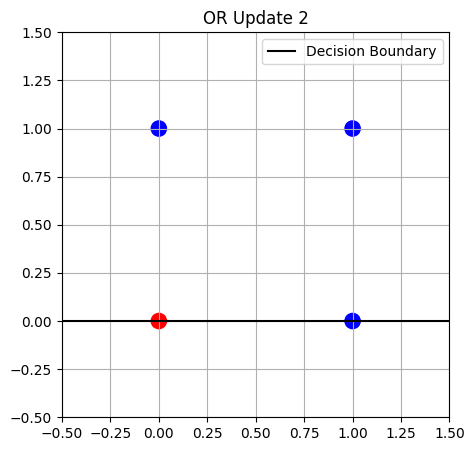


Update 3
Input : [0 0]
Target : 0
Prediction : 1
Weights : [0.  0.1]
Bias : -0.1


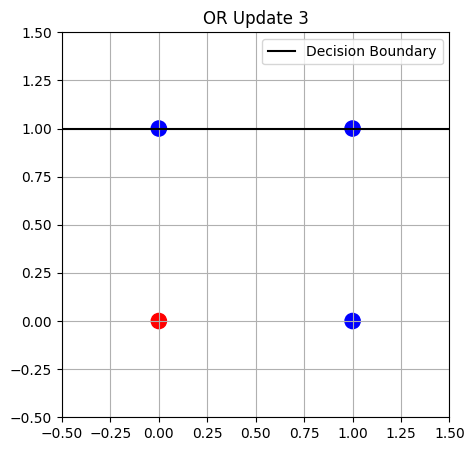


Update 4
Input : [1 0]
Target : 1
Prediction : 0
Weights : [0.1 0.1]
Bias : 0.0


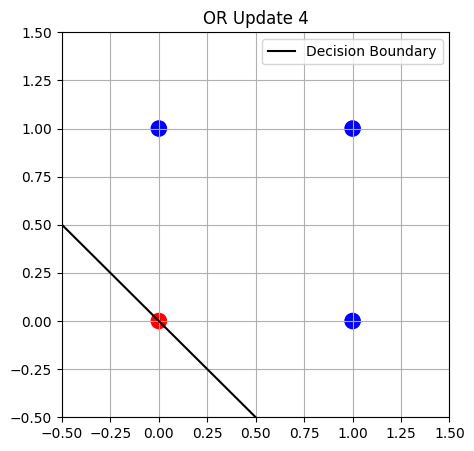


Update 5
Input : [0 0]
Target : 0
Prediction : 1
Weights : [0.1 0.1]
Bias : -0.1


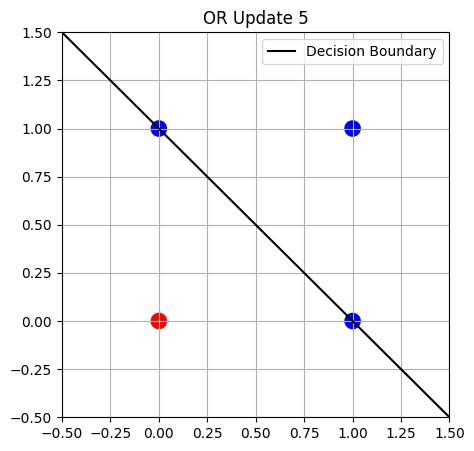


Converged Successfully!

Final Weights : [0.1 0.1]
Final Bias : -0.1
Predictions : [0 1 1 1]


In [24]:
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y = np.array([0,1,1,1])

model = Perceptron(lr=0.1, epochs=20)
model.fit(X, y, "OR")


Training Perceptron for NOT

Update 1
Input : [1]
Target : 0
Prediction : 1
Weights : [-0.1]
Bias : -0.1


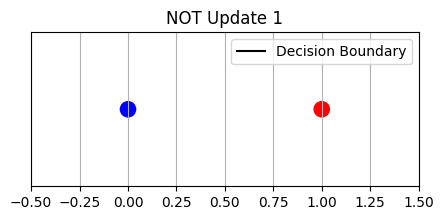


Update 2
Input : [0]
Target : 1
Prediction : 0
Weights : [-0.1]
Bias : 0.0


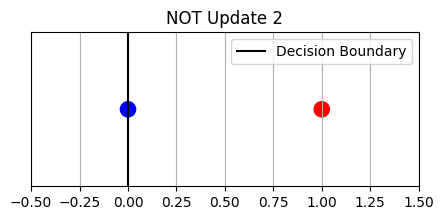


Converged Successfully!

Final Weights : [-0.1]
Final Bias : 0.0
Predictions : [1 0]


In [25]:
X = np.array([
    [0],
    [1]
])

y = np.array([1,0])

model = Perceptron(lr=0.1, epochs=20)
model.fit(X, y, "NOT")


Training Perceptron for XOR

Update 1
Input : [0 0]
Target : 0
Prediction : 1
Weights : [0. 0.]
Bias : -0.1


/tmp/ipykernel_4494/1771394628.py:67: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


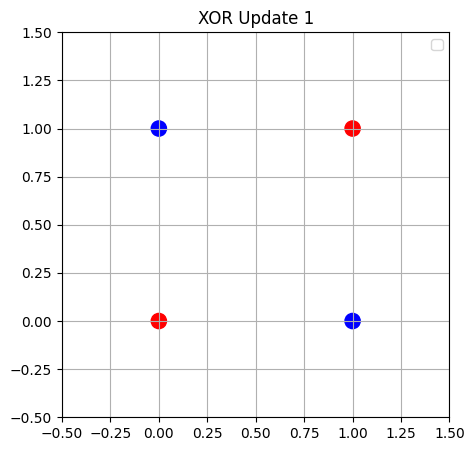


Update 2
Input : [0 1]
Target : 1
Prediction : 0
Weights : [0.  0.1]
Bias : 0.0


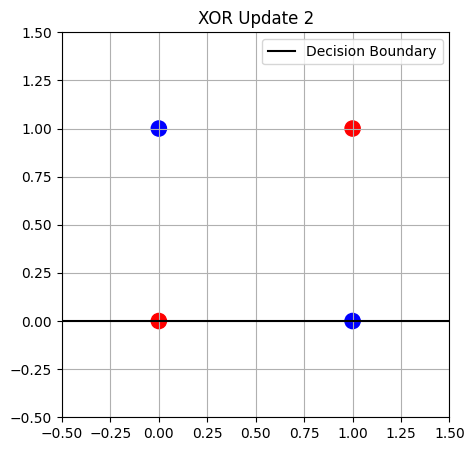


Update 3
Input : [1 1]
Target : 0
Prediction : 1
Weights : [-0.1  0. ]
Bias : -0.1


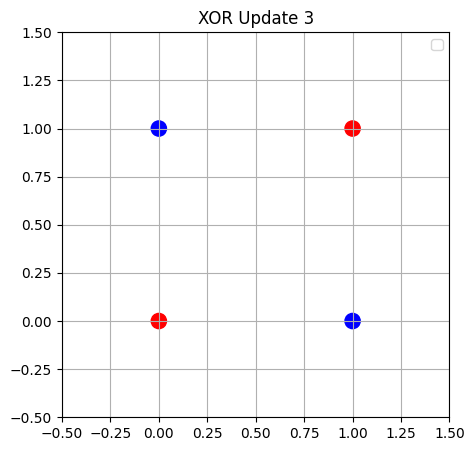


Update 4
Input : [0 1]
Target : 1
Prediction : 0
Weights : [-0.1  0.1]
Bias : 0.0


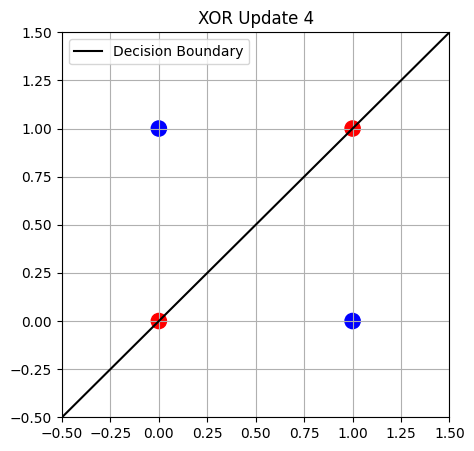


Update 5
Input : [1 0]
Target : 1
Prediction : 0
Weights : [0.  0.1]
Bias : 0.1


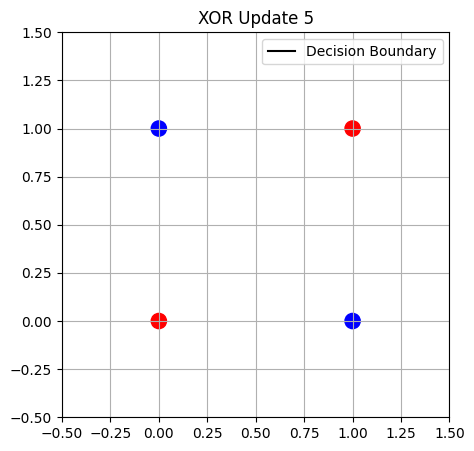


Update 6
Input : [1 1]
Target : 0
Prediction : 1
Weights : [-0.1  0. ]
Bias : 0.0


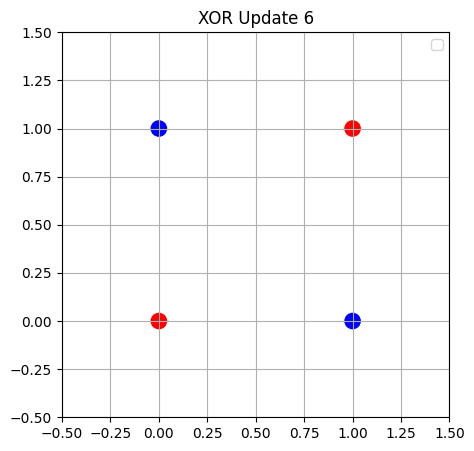


Update 7
Input : [0 0]
Target : 0
Prediction : 1
Weights : [-0.1  0. ]
Bias : -0.1


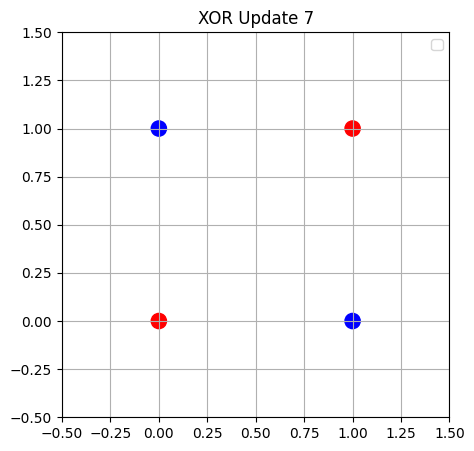


Update 8
Input : [0 1]
Target : 1
Prediction : 0
Weights : [-0.1  0.1]
Bias : 0.0


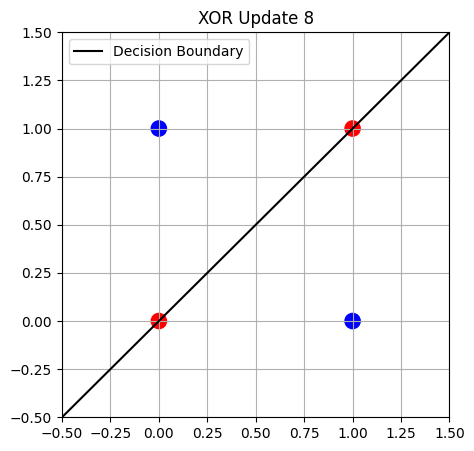


Update 9
Input : [1 0]
Target : 1
Prediction : 0
Weights : [0.  0.1]
Bias : 0.1


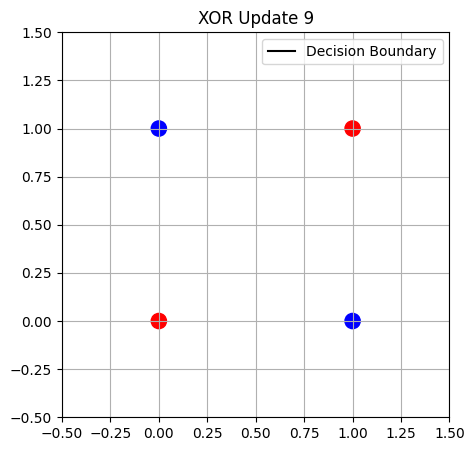


Update 10
Input : [1 1]
Target : 0
Prediction : 1
Weights : [-0.1  0. ]
Bias : 0.0


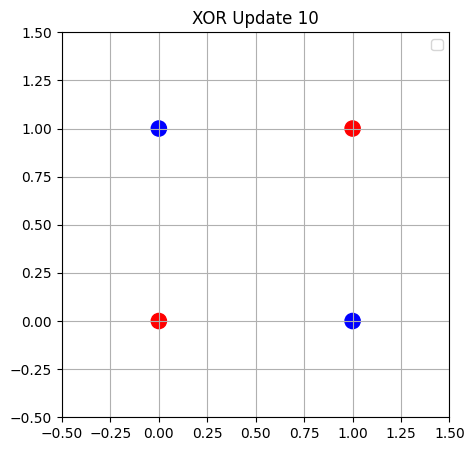


Update 11
Input : [0 0]
Target : 0
Prediction : 1
Weights : [-0.1  0. ]
Bias : -0.1

Update 12
Input : [0 1]
Target : 1
Prediction : 0
Weights : [-0.1  0.1]
Bias : 0.0

Update 13
Input : [1 0]
Target : 1
Prediction : 0
Weights : [0.  0.1]
Bias : 0.1

Update 14
Input : [1 1]
Target : 0
Prediction : 1
Weights : [-0.1  0. ]
Bias : 0.0

Update 15
Input : [0 0]
Target : 0
Prediction : 1
Weights : [-0.1  0. ]
Bias : -0.1

Update 16
Input : [0 1]
Target : 1
Prediction : 0
Weights : [-0.1  0.1]
Bias : 0.0

Update 17
Input : [1 0]
Target : 1
Prediction : 0
Weights : [0.  0.1]
Bias : 0.1

Update 18
Input : [1 1]
Target : 0
Prediction : 1
Weights : [-0.1  0. ]
Bias : 0.0

Update 19
Input : [0 0]
Target : 0
Prediction : 1
Weights : [-0.1  0. ]
Bias : -0.1

Update 20
Input : [0 1]
Target : 1
Prediction : 0
Weights : [-0.1  0.1]
Bias : 0.0

Update 21
Input : [1 0]
Target : 1
Prediction : 0
Weights : [0.  0.1]
Bias : 0.1

Update 22
Input : [1 1]
Target : 0
Prediction : 1
Weights : [-0.1  0. ]
Bias :

In [26]:
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y = np.array([0,1,1,0])

model = Perceptron(lr=0.1, epochs=20)
model.fit(X, y, "XOR")